# KNN
- Dataset: 
    1. Titanic https://www.kaggle.com/datasets/yasserh/titanic-dataset
    2. Wine https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
    3. Breast Cancer https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [11]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#knn logic
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
        
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    
    return Counter(k_nearest_labels).most_common(1)[0][0]

#knn helper function
def run_generic_knn(file_path, target_col, k=5, cols_to_drop=None):
    print(f"Loading and processing: {file_path}...")
    
    #load dataset
    df = pd.read_csv(file_path)
    
    #drop unnecessary columns (like IDs, Names, etc.)
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop, errors='ignore')
        
    #features (X) and target (y)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    #identify categorical and numerical columns
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X.select_dtypes(include=['object', 'category', 'str']).columns
    
    #Preprocessing
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    #preprocess the feature data entirely
    X_processed = preprocessor.fit_transform(X)
    
    #Convert target to a flat NumPy array (prevents index errors in custom loop)
    y_array = y.to_numpy()
    
    #split data - train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y_array, test_size=0.3, random_state=42
    )
    
    #predict
    predictions = []
    for test_point in X_test:
        pred = knn_predict(X_train, y_train, test_point, k)
        predictions.append(pred)
        
    #evaluate
    accuracy = accuracy_score(y_test, predictions)
    print(f"Results for {file_path}")
    print(f"Accuracy: {accuracy:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, predictions, zero_division=0))

    #Confusion Matrix
    #Create confusion matrix
    cm = confusion_matrix(y_test, predictions)

    #Plot it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title("Confusion Matrix")
    plt.show()

    cm = confusion_matrix(y_test, predictions)
    print(cm)
    
    return predictions, y_test

Loading and processing: WineQT.csv...
Results for WineQT.csv
Accuracy: 0.5394

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         9
           5       0.59      0.64      0.61       143
           6       0.53      0.53      0.53       146
           7       0.41      0.39      0.40        41
           8       0.00      0.00      0.00         4

    accuracy                           0.54       343
   macro avg       0.31      0.31      0.31       343
weighted avg       0.52      0.54      0.53       343



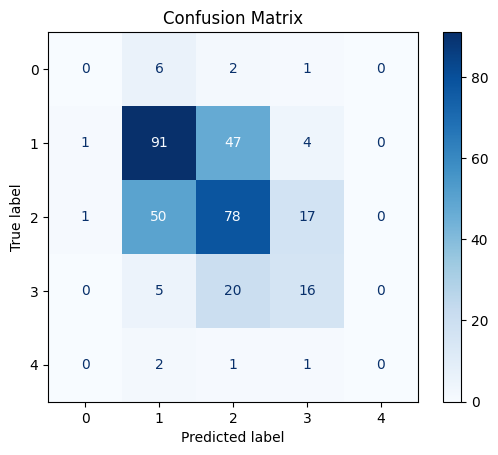

[[ 0  6  2  1  0]
 [ 1 91 47  4  0]
 [ 1 50 78 17  0]
 [ 0  5 20 16  0]
 [ 0  2  1  1  0]]


In [12]:
wine_preds, wine_actual = run_generic_knn(
    file_path='WineQT.csv', 
    target_col='quality',
    k=5
)

Loading and processing: Titanic-Dataset.csv...
Results for Titanic-Dataset.csv
Accuracy: 0.7910

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.83       157
           1       0.80      0.66      0.72       111

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268



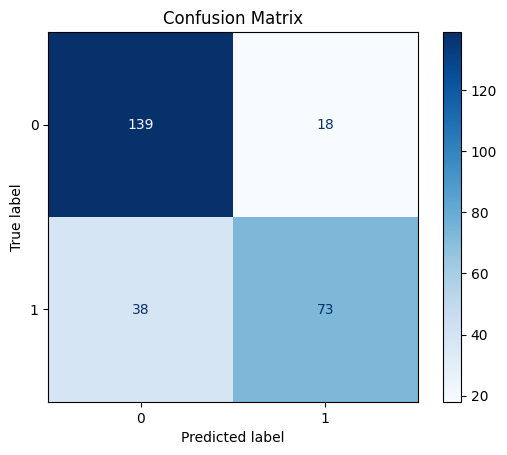

[[139  18]
 [ 38  73]]


In [13]:
titanic_preds, titanic_actual = run_generic_knn(
    file_path='Titanic-Dataset.csv', 
    target_col='Survived',
    k=5,
    cols_to_drop=['PassengerId', 'Name', 'Ticket', 'Cabin']
)

Loading and processing: BreastCancer.csv...
Results for BreastCancer.csv
Accuracy: 0.9591

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.97      0.97       108
           M       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



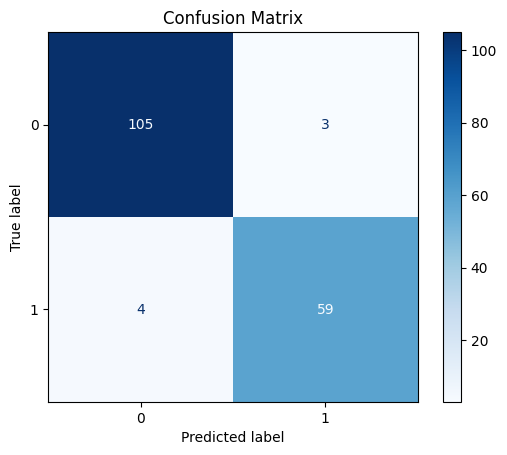

[[105   3]
 [  4  59]]


In [14]:
cancer_preds, cancer_actual = run_generic_knn(
    file_path='BreastCancer.csv', 
    target_col='diagnosis', #'M' for malignant, 'B' for benign
    k=5,
    cols_to_drop=['id','Unnamed: 32']
)